In [3]:
from netective.stats import stats

In [4]:
from netective.utils import parse_network
# pred = 'short_100226_v2019_sFL_dAllInc_BSs.pred'
pred = '100226_v2019_sFL_dAllInc_BSs.pred'
pred_2 = 'MEME.pred'
# gs = 'short_GS.txt'
gs = 'GS.txt'
pred_graph = parse_network(pred, delimiter='\t', directed=True, score=True, use_position_as_score=False)
pred_graph_2 = parse_network(pred_2, delimiter='\t', directed=True, score=True, use_position_as_score=False)
gold_standard_graph = parse_network(gs, delimiter='\t', directed=True, score=False, use_position_as_score=False)
bin_stats = stats.LinkEval(gold_standard_graph, pred_graph, greater_score_is_better=False, allow_self_loops=True)
pred_graph.is_directed(), pred_graph.edges(data=True)

(True,
 OutEdgeDataView([('SCO3361', 'SCO3362', {'score': 5.333333333333333}), ('SCO3361', 'SCO3361', {'score': 5.333333333333333}), ('SCO3361', 'SCO4184', {'score': 212.0}), ('SCO3361', 'SCO4183', {'score': 212.0}), ('SCO3361', 'SCO3605', {'score': 239.33333333333334}), ('SCO3361', 'SCO1496', {'score': 435.3333333333333}), ('SCO3361', 'SCO4077', {'score': 605.0}), ('SCO3361', 'SCO4076', {'score': 605.0}), ('SCO3361', 'SCO5444', {'score': 634.3333333333334}), ('SCO3361', 'SCO5443', {'score': 634.3333333333334}), ('SCO3361', 'SCO6005', {'score': 672.6666666666666}), ('SCO3361', 'SCO2604', {'score': 716.0}), ('SCO3361', 'SCO0431', {'score': 738.6666666666666}), ('SCO3361', 'SCO2003', {'score': 838.3333333333334}), ('SCO3361', 'SCO2004', {'score': 838.3333333333334}), ('SCO3361', 'SCO0432', {'score': 839.3333333333334}), ('SCO3361', 'SCO5660', {'score': 858.6666666666666}), ('SCO3361', 'SCO1999', {'score': 883.6666666666666}), ('SCO3361', 'SCO7600', {'score': 921.6666666666666}), ('SCO336

In [5]:
bin_stats.area_under_roc_curve(), bin_stats.area_under_precision_recall_curve()

(0.7692916019153007, 0.46772006085898515)

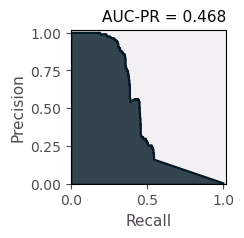

In [6]:
ax = bin_stats.plot_precision_recall_curve()

In [7]:
# ax = bin_stats.plot_precision_recall_curve(cutoff=400)


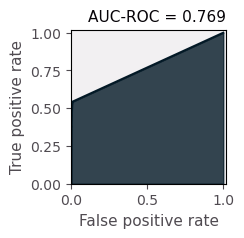

In [8]:
ax = bin_stats.plot_roc_curve()


In [ ]:
# bin_stats.cutoff = 100

In [ ]:
ax = bin_stats.plot_precision_recall_curve()

In [ ]:
ax

In [ ]:
bin_stats.accuracy(), bin_stats.precision(), bin_stats.recall(), bin_stats.optimal_cutoff(), bin_stats.f1_score()

In [ ]:
bin_stats.cutoff

In [ ]:
ax = bin_stats.optimal_cutoff_plot()

In [ ]:
bin_stats.optimal_cutoff_plot().set_xscale('log')

In [ ]:
import networkx as nx

# create gold standard graph
gold_standard_graph = nx.Graph()
gold_standard_graph.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 5), (4, 6), (5, 6)])

# create prediction graph 1
pred_graph_1 = nx.Graph()
pred_graph_1.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 5)])

# create prediction graph 2
pred_graph_2 = nx.Graph()
pred_graph_2.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 6), (5, 6)])

# create prediction graph 3
pred_graph_3 = nx.Graph()
pred_graph_3.add_edges_from([(1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (4, 5), (4, 6), (5, 6), (6, 1)])

In [ ]:
from random import random

# add different weights to prediction graph 1
for u, v, d in pred_graph_1.edges(data=True):
    d['score'] = random()

# add different weights to prediction graph 2
for u, v, d in pred_graph_2.edges(data=True):
    d['score'] = random()

# add different weights to prediction graph 3
for u, v, d in pred_graph_3.edges(data=True):
    d['score'] = random()


In [ ]:
from netective.stats.stats import Benchmark

preds = {'pred_graph_1': pred_graph_1, 'pred_graph_2': pred_graph_2, 'pred_graph_3': pred_graph_3}
# gold_standard_edges, inference_edges, size_universe = _anonymize_edges(gold_standard_graph.edges(), pred_graph_1.edges())
foo = Benchmark(gold_standard_graph, preds, greater_score_is_better=True, allow_self_loops=True)

In [ ]:
foo.plot_roc_curves()

In [ ]:
foo.plot_precision_recall_curves()

In [ ]:
import seaborn as sns
[tuple(c) for c in sns.color_palette("pastel", n_colors=4)]


In [ ]:
ax = foo.plot_optimal_cutoffs()

In [ ]:
pred_graph_2.edges(data=True)

In [36]:
gold_standard_graph

In [9]:
from netective.stats.stats import Benchmark

networks = {'Exp': pred_graph, 'MEME': pred_graph_2}
benchmark = Benchmark(gold_standard_graph, networks, greater_score_is_better=False, allow_self_loops=True)

<Axes: xlabel='Recall', ylabel='Precision'>

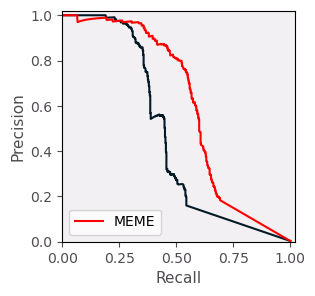

In [11]:
benchmark.plot_precision_recall_curves()

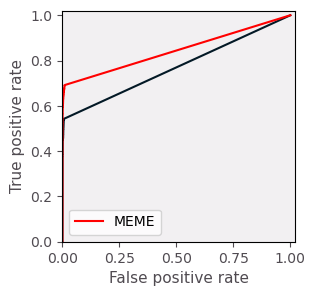

In [12]:
ax = benchmark.plot_roc_curves()

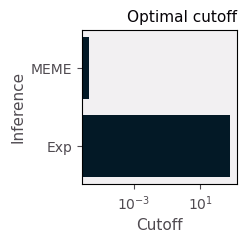

In [13]:
benchmark.plot_optimal_cutoffs().set_xscale('log')

In [14]:
benchmark.best_auroc()

('MEME', 0.8437201083134056)

In [7]:
benchmark.best_aupr(), benchmark.best_f1_score(),  benchmark.best_accuracy(), benchmark.best_precision(), benchmark.best_recall(), benchmark.best_mcc()

(('pred_2', 0.6032994493883853),
 ('pred_2', 0.28995633187772923),
 ('pred_1', 0.9893903277714347),
 ('pred_2', 0.18342541436464088),
 ('pred_2', 0.6916666666666667),
 ('pred_2', 0.35266319656622336))

(<Axes: title={'right': 'AUPR'}, xlabel='AUPR', ylabel='Inference'>,
 <Axes: title={'right': 'AUROC'}, xlabel='AUROC', ylabel='Inference'>,
 <Axes: title={'right': 'F1 score'}, xlabel='F1 score', ylabel='Inference'>,
 <Axes: title={'right': 'MCC'}, xlabel='MCC', ylabel='Inference'>)

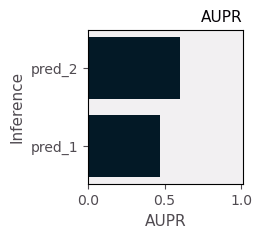

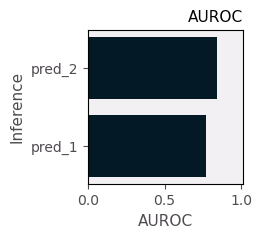

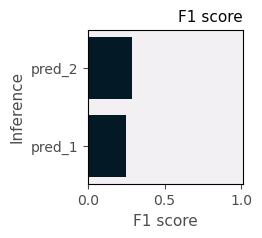

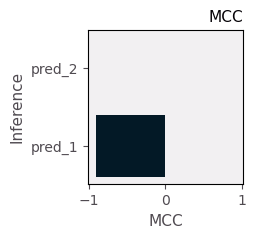

In [8]:
benchmark.plot_aupr(), benchmark.plot_auroc(), benchmark.plot_f1_score(), benchmark.plot_mcc()

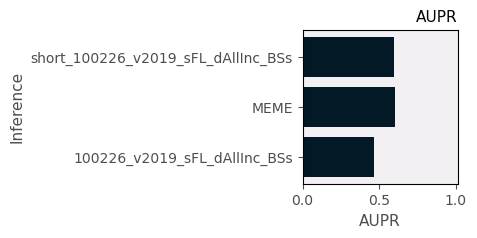

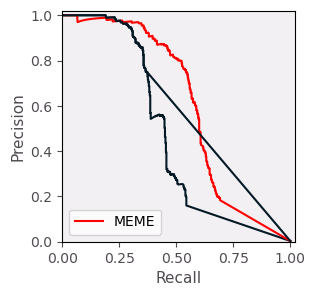

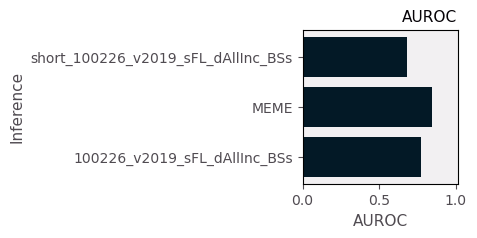

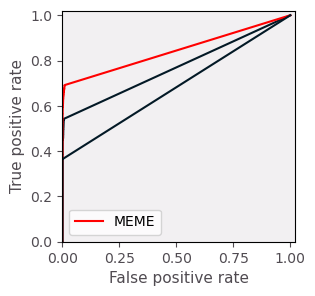

In [2]:
from netective import benchmarking

preds = './preds'
gs = 'GS.txt'

fig_aupr, fig_pr_curves, fig_auroc, fig_roc_curves = benchmarking(preds, gs, greater_score_is_better=False, allow_self_loops=True, score=True, return_auc_dicts=False)

In [3]:
fig_aupr, fig_pr_curves, fig_auroc, fig_roc_curves

(<Axes: title={'right': 'AUPR'}, xlabel='AUPR', ylabel='Inference'>,
 <Axes: xlabel='Recall', ylabel='Precision'>,
 <Axes: title={'right': 'AUROC'}, xlabel='AUROC', ylabel='Inference'>,
 <Axes: xlabel='False positive rate', ylabel='True positive rate'>)

In [6]:
G = ns['short_GS']
G.edges(data=True)

OutEdgeDataView([('SCO0194', 'SCO0185', {}), ('SCO0194', 'SCO0186', {}), ('SCO0194', 'SCO0187', {}), ('SCO0194', 'SCO0188', {}), ('SCO0194', 'SCO0189', {}), ('SCO0194', 'SCO0190', {}), ('SCO0194', 'SCO0191', {}), ('SCO0194', 'SCO0194', {}), ('SCO0194', 'SCO0195', {}), ('SCO0194', 'SCO0196', {}), ('SCO0204', 'SCO0200', {}), ('SCO0204', 'SCO0204', {}), ('SCO0204', 'SCO0207', {}), ('SCO0204', 'SCO0208', {}), ('SCO0204', 'SCO1541', {}), ('SCO0204', 'SCO2967', {}), ('SCO0204', 'SCO5320', {}), ('SCO0204', 'SCO5321', {}), ('SCO0204', 'SCO5978', {}), ('SCO0204', 'SCO5979', {}), ('SCO0204', 'SCO6040', {}), ('SCO0204', 'SCO6041', {}), ('SCO0310', 'SCO5085', {}), ('SCO0561', 'SCO0560', {}), ('SCO0561', 'SCO0561', {}), ('SCO0599', 'SCO0600', {}), ('SCO0600', 'SCO0600', {}), ('SCO0600', 'SCO0666', {}), ('SCO0600', 'SCO0885', {}), ('SCO0600', 'SCO1663', {}), ('SCO0600', 'SCO2372', {}), ('SCO0600', 'SCO3068', {}), ('SCO0600', 'SCO3202', {}), ('SCO0600', 'SCO4204', {}), ('SCO0600', 'SCO5085', {}), ('S